# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
!pip install pandas numpy matplotlib seaborn japanize-matplotlib
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # untuk tampilan teks Jepang (optional)

# Setting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 1.4 MB/s  0:00:031.3 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4127494 sha256=4c2ed6c61e0629bbe522d3eeda4e18df51c54236961b1d7aec46caa032854910
  Stored in directory: /home/kopiadem/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:

# Set the path to the file you'd like to load
file_path = "japanese_universities.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "webdevbadger/japanese-universities",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_82226/2614097908.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Unnamed: 0           code  \
0           0  F101110100010   
1           1  F101110100029   
2           2  F101110100038   
3           3  F101110100047   
4           4  F101110100056   

                                                name  name_jp      type  \
0                                Hokkaido University    北海道大学  National   
1                   Hokkaido University of Education  北海道教育大学  National   
2                    Muroran Institute of Technology   室蘭工業大学  National   
3                       Otaru University of Commerce   小樽商科大学  National   
4  Obihiro University of Agriculture And Veterina...   帯広畜産大学  National   

  type_jp              address postal_code         phone      state  ...  \
0      国立      北海道札幌市北区北8条西5丁目    060－0808  011－716－2111  Hokkai Do  ...   
1      国立  北海道札幌市北区あいの里5条3－1－3    002－8501  011－778－0206  Hokkai Do  ...   
2      国立        北海道室蘭市水元町27－1    050－8585  0143－46－5000  Hokkai Do  ...   
3      国立        北海道小樽市緑3－5－21    0

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
#Type your code here

## Gambaran Umum Data

In [7]:
# Melihat 5 baris pertama
print(df.head())

# Informasi tipe data dan non-null count
print(df.info())

# Statistik deskriptif untuk kolom numerik
print(df.describe())

# Statistik untuk kolom kategorikal
print(df.describe(include=['object', 'bool']))

   Unnamed: 0           code  \
0           0  F101110100010   
1           1  F101110100029   
2           2  F101110100038   
3           3  F101110100047   
4           4  F101110100056   

                                                name  name_jp      type  \
0                                Hokkaido University    北海道大学  National   
1                   Hokkaido University of Education  北海道教育大学  National   
2                    Muroran Institute of Technology   室蘭工業大学  National   
3                       Otaru University of Commerce   小樽商科大学  National   
4  Obihiro University of Agriculture And Veterina...   帯広畜産大学  National   

  type_jp              address postal_code         phone      state  ...  \
0      国立      北海道札幌市北区北8条西5丁目    060－0808  011－716－2111  Hokkai Do  ...   
1      国立  北海道札幌市北区あいの里5条3－1－3    002－8501  011－778－0206  Hokkai Do  ...   
2      国立        北海道室蘭市水元町27－1    050－8585  0143－46－5000  Hokkai Do  ...   
3      国立        北海道小樽市緑3－5－21    047－8501  0134－27－

## Cek Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False))

                 Missing  Percentage
difficulty_rank       59    7.257073
difficulty_SD         59    7.257073
review_count          15    1.845018
review_rating         15    1.845018
phone                  3    0.369004


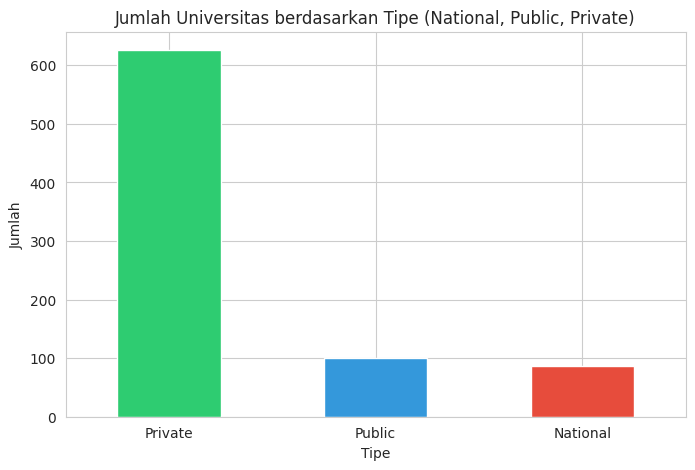

In [9]:
plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'])
plt.title('Jumlah Universitas berdasarkan Tipe (National, Public, Private)')
plt.xlabel('Tipe')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

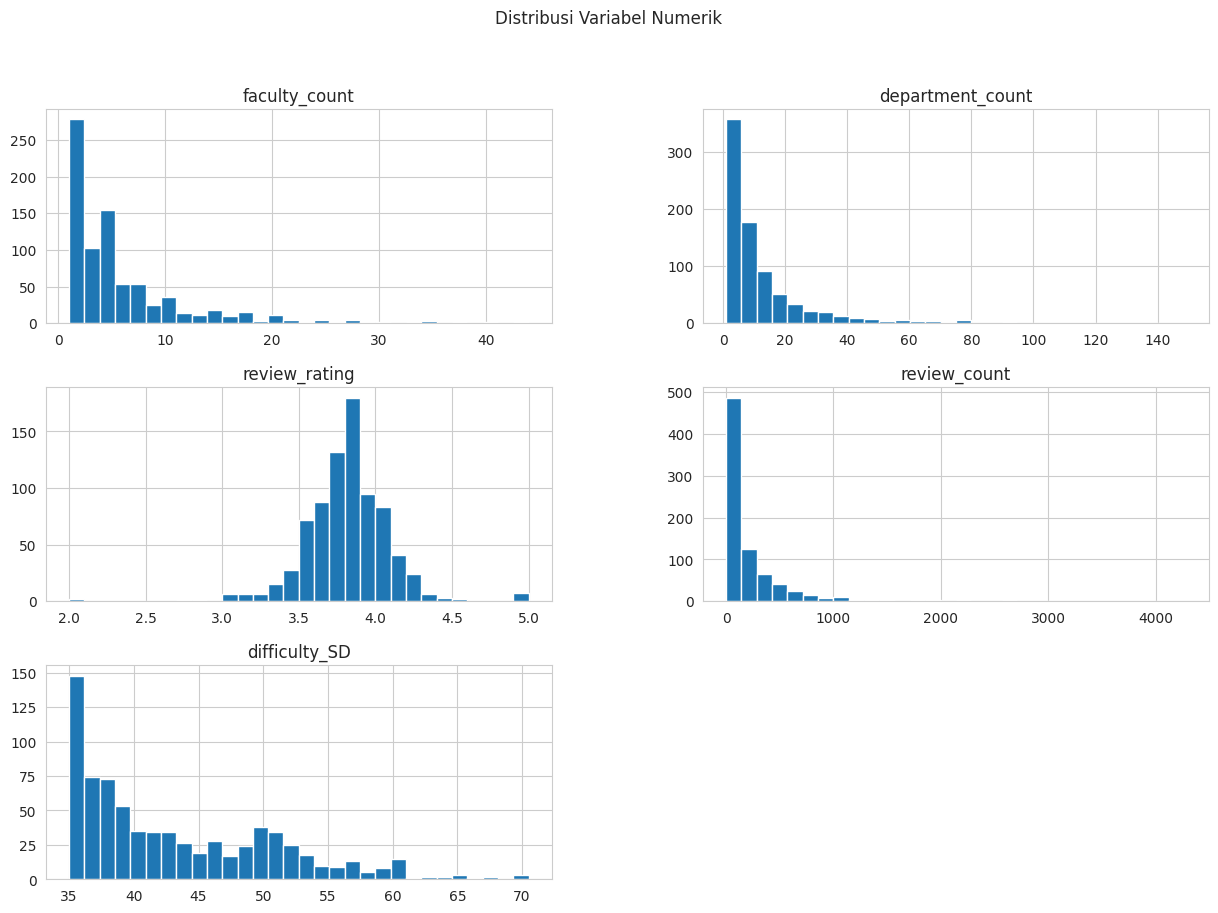

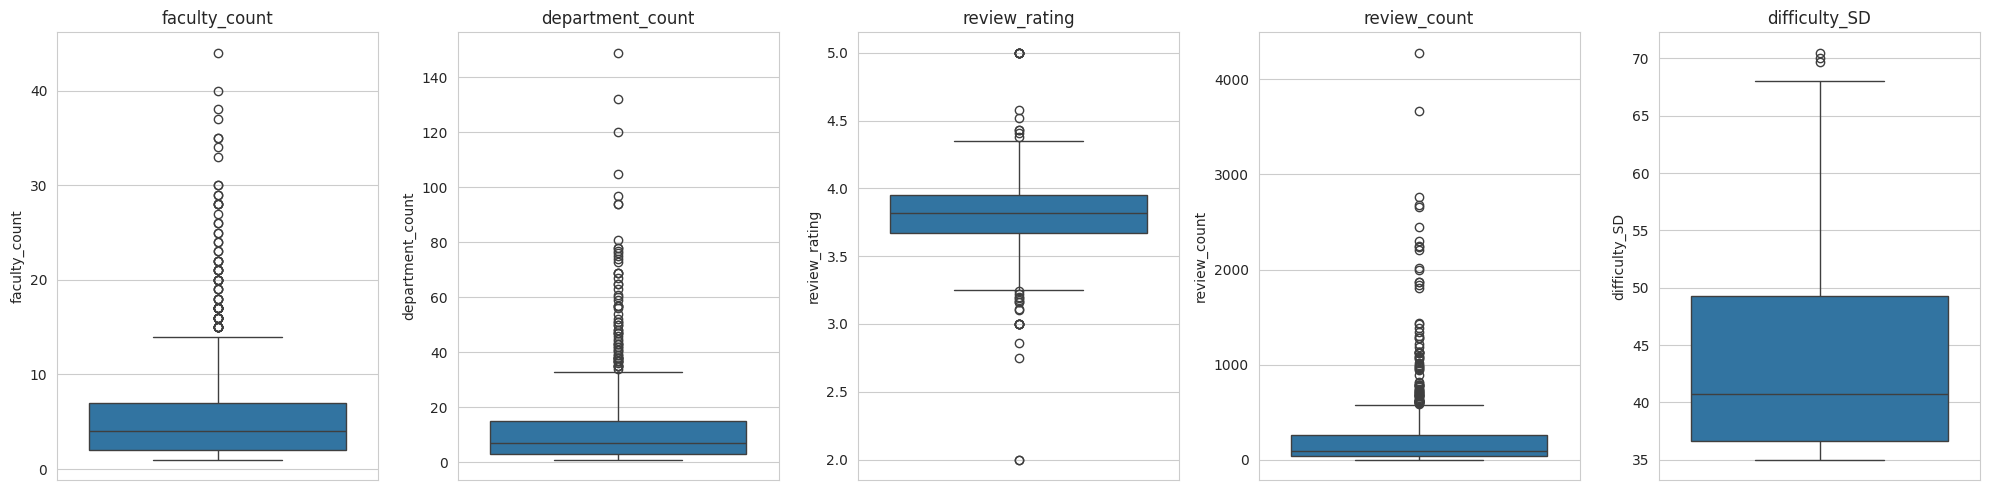

In [10]:
num_cols = ['faculty_count', 'department_count', 'review_rating', 'review_count', 'difficulty_SD']
df[num_cols].hist(bins=30, figsize=(15,10))
plt.suptitle('Distribusi Variabel Numerik')
plt.show()

# Boxplot untuk mendeteksi outlier
fig, ax = plt.subplots(1, len(num_cols), figsize=(20,5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()
plt.show()

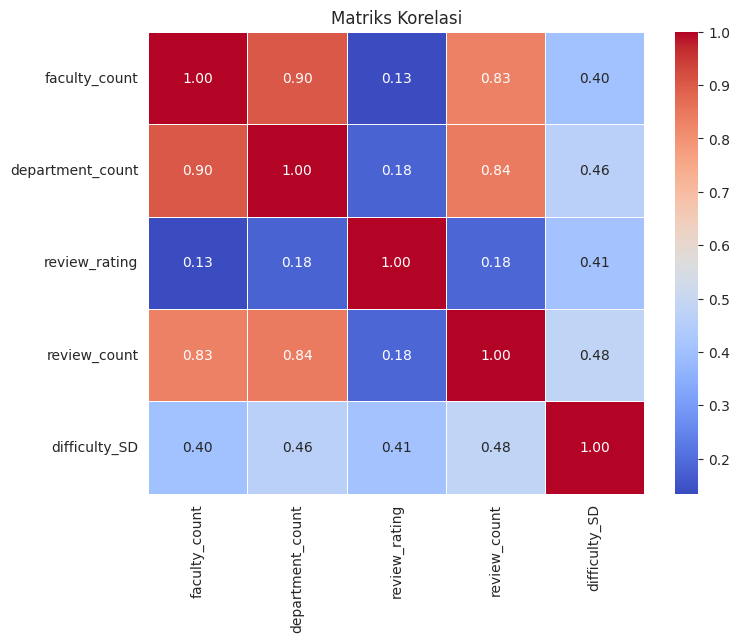

In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi')
plt.show()

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x='difficulty_rank', y='review_rating', data=df, order=rank_order)
plt.title('Rating Review berdasarkan Peringkat Kesulitan')
plt.show()

NameError: name 'rank_order' is not defined

<Figure size 1000x600 with 0 Axes>

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.